# TP : Méthode de seuillage par détection des vallées
- **Cursus** : Licence INFO S7 TREC7
- **UE** : Analyse d'images (27_0194)
- **Etudiant** : Roland MUGNIER

## Choix des outils

Nous avons le choix entre matlab, scilab et python pour la réalisation de ce TP à rendre.

J'ai choisi python car la fonctionalité de Jupyter notebook permet de rendre une documentation plus soignée de l'implémentation du TP.

Les blocs de citations sont l'énoncé du TP, nous descendrons l'énoncé au fur à mesure avant d'implémenter les fonctions demandées.

## Réalisation du TP

> Le but de ce TP est d'implémenter la méthode de seuillage par détection des vallées. Comme vu dans le cours pour détecter les seuils permettant de segmenter l'image en objets où chaque objet est représenté par une modalité de l'histogramme.
> 
> Pour détecter les modes (les pics maxima) on pourra utiliser par exemple le principe suivant :
> 
> Soit $h$ un histogramme tel que $h(i) \in [0,1]$ avec $0 ≤ i ≤ 255$.

Nous n'avons pas encore défini de formule pour calculer l'histogramme en python, suivant notre code existant scilab, nous allons définir les fonctions suivantes :
- __load_image_matrix__ : pour charger une image et la convertir en matrice de valeurs de pixels en niveau de gris
- __compute_histogram__ : pour calculer l'histogramme de l'image à partir de la matrice de valeurs de pixels

In [1]:
import numpy as np
from PIL import Image

def load_image_matrix(image_path: str, *, show: bool = False) -> np.ndarray:
    """Charge une image en niveaux de gris et retourne une matrice uint8 (valeurs 0..255)."""

    img_rgb = Image.open(image_path)

    # Array numpy, objet d'une librarie très utilisée pour les calculs matriciels
    img_array = np.array(img_rgb)

    # Cas particulier des images indexées (mode P) : on remplace les indices par les couleurs de la palette
    if img_rgb.mode == "P":
        palette = np.array(img_rgb.getpalette(), dtype=np.uint8).reshape(-1, 3)
        img_array = palette[img_array]

    # On s'assure que c'est une image couleur (3 dimensions)
    if len(img_array.shape) == 3:
        if img_array.shape[2] >= 3:
            # RGB ou RGBA: on ignore l'alpha en ne gardant que les 3 premiers canaux
            img_array = img_array[:, :, :3]
            
            # Conversion vectorielle en niveaux de gris via numpy (standard "ITU-R 601-2 luma transform"):
            # L = R * 299/1000 + G * 587/1000 + B * 114/1000
            matrix = np.dot(img_array, [0.299, 0.587, 0.114]).astype(np.uint8)
        else:
            # Image avec 2 canaux (ex: LA = Luminance + Alpha)
            # On récupère seulement le premier canal (Luminance) et on ignore l'alpha
            matrix = img_array[:, :, 0].astype(np.uint8)
    else:
        # Image déjà en niveaux de gris (2 dimensions : W x H)
        # On converti en une matrice de type uint8 (valeurs 0..255)
        matrix = img_array.astype(np.uint8)

    if show:
        print(matrix)
        print(
            f"shape={matrix.shape}, dtype={matrix.dtype}, min={matrix.min()}, max={matrix.max()}"
        )

    return matrix

On teste la fonction __load_image_matrix__ sur une image d'exemple pour appréhender la matrice retournée ainsi que quelques métriques pour résumé l'image (type, dimensions, valeurs min et max)

In [2]:

m = load_image_matrix(image_path="img/lena.png", show=True)

[[162 162 162 ... 169 154 128]
 [162 162 162 ... 169 154 128]
 [162 162 162 ... 169 154 128]
 ...
 [ 42  42  49 ... 104 100  98]
 [ 43  43  54 ... 103 105 107]
 [ 43  43  54 ... 103 105 107]]
shape=(512, 512), dtype=uint8, min=24, max=245


shape=(256,), dtype=float64, sum=262144.000000, min=0.000000, max=2782.000000


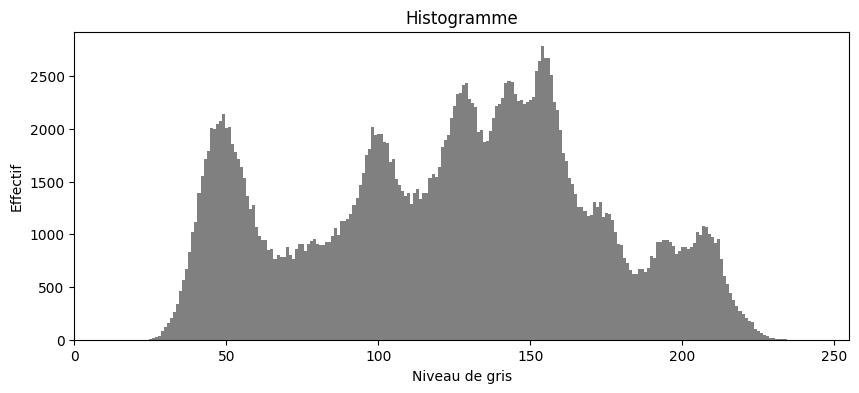

In [3]:
def compute_histogram(matrix: np.ndarray, *, normalized: bool = True) -> np.ndarray:
    """Calcule l'histogramme (256 niveaux) d'une image en niveaux de gris.

    Args:
        matrix: Matrice d'image uint8 (2D) ou tableau équivalent de valeurs 0..255.
        normalized: Si True, retourne un histogramme normalisé dans [0, 1] dont la somme vaut 1.

    Returns:
        np.ndarray: Vecteur de taille 256 contenant les effectifs (ou fréquences) par intensité.
    """

    # Aplatit la matrice pour obtenir un seul vecteur de pixels avec la méthode ravel.
    flat = np.asarray(matrix, dtype=np.uint8).ravel()

    # bincount compte les occurrences de chaque valeur entière dans flat, jusqu'à 255 (minlength=256).
    # float64 car pour les grandes images, les effectifs peuvent dépasser le type intp (tpye numpy).
    hist = np.bincount(flat, minlength=256).astype(np.float64)

    if normalized:
        total = flat.size
        if total > 0:
            hist /= total

    return hist


# Test rapide avec l'image déjà chargée dans m
h = compute_histogram(m, normalized=False)
print(f"shape={h.shape}, dtype={h.dtype}, sum={h.sum():.6f}, min={h.min():.6f}, max={h.max():.6f}")

# Affichage de l'histogramme
# La librarie matplotlib est la plus connue pour réaliser des graphiques sur python
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(range(256), h, width=1, color='gray')
plt.xlim(xmin=0, xmax=255)
plt.title("Histogramme")
plt.xlabel("Niveau de gris")
plt.ylabel("Effectif")
plt.show()

On aura besoin du même histogramme mais normalisé pour la suite, on en profite pour s'assurer que la forme de l'histogramme ne change pas :

shape=(256,), dtype=float64, sum=1.000000, min=0.000000, max=0.010612


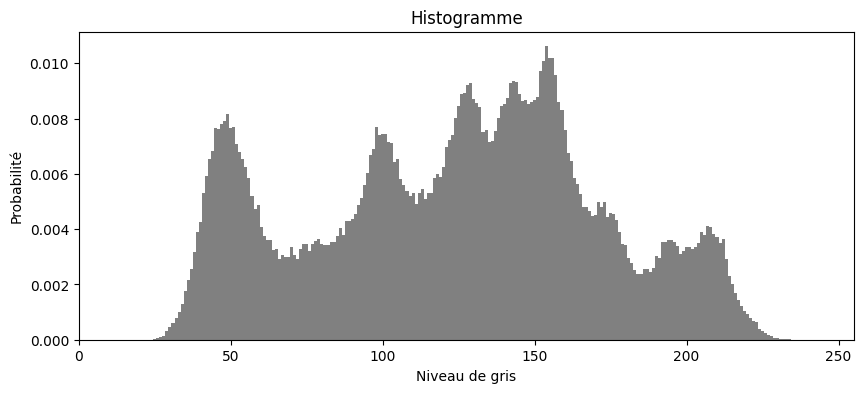

In [4]:
h = compute_histogram(m, normalized=True)
print(f"shape={h.shape}, dtype={h.dtype}, sum={h.sum():.6f}, min={h.min():.6f}, max={h.max():.6f}")

# Affichage de l'histogramme
# La librarie matplotlib est la plus connue pour réaliser des graphiques sur python

plt.figure(figsize=(10, 4))
plt.bar(range(256), h, width=1, color='gray')
plt.xlim(xmin=0, xmax=255)
plt.title("Histogramme")
plt.xlabel("Niveau de gris")
plt.ylabel("Probabilité")
plt.show()

> Soit h un histogramme tel que $h(i) \in [0,1]$ avec $0 \le i \le 255$. L'algorithme de recherche des pics est le suivant :
>  - Trouver tous les pics : trouver l'ensemble $P_0$ des points qui sont des maxima locaux dans l'histogramme.
> $$P_0 = \{ (i, h(i)) \mid h(i) > h(i-1) \text{ et } h(i) > h(i+1),\; 1 \le i \le 254 \}$$

On sait qu'on recherche les pics sur un histogramme normalisé car $h(i) \in [0,1]$. On exclu les extrèmes de l'histogramme (0 et 255) car la formule donnée prend en compte le voisin de droite et de gauche : pour que ce soit un pic, il faut que leurs valeurs soient inférieures à celle du pic.  Nous allons définir la fonction suivante :
- __compute_peaks__ : retourne l'ensemble $P_0$ des points qui sont des maxima locaux dans l'histogramme.



In [5]:
def compute_local_peaks(h: np.ndarray, iterations: int = 1) -> list[tuple[int, float]]:
    """
    Retourne l'ensemble des points qui sont des maxima locaux dans un tableau.
    Applique le processus 'iterations' fois pour obtenir des pics plus significatifs.
    
    Args:
        h: np.ndarray, un tableau.
        iterations: le nombre d'itérations de filtrage (1 pour P_0, 2 pour P_1, etc.).
        
    Returns:
        Une liste de tuples (i, h[i]) pour chaque pic trouvé.
    """
    # 1ère itération (P_0) : on cherche sur le tableau complet `h`
    peaks = []
    for i in range(1, len(h) - 1):
        if h[i] > h[i-1] and h[i] > h[i+1]:
            peaks.append((i, h[i]))
            
    # Itérations suivantes (P_1, P_2, ...) sur la liste de pics existante
    for _ in range(1, iterations):
        new_peaks = []
        for i in range(1, len(peaks) - 1):
            if peaks[i][1] > peaks[i-1][1] and peaks[i][1] > peaks[i+1][1]:
                new_peaks.append(peaks[i])
        peaks = new_peaks
        
    return peaks

In [6]:

peaks = compute_local_peaks(h)
print(f"Nombre de pics: {len(peaks)}")

print(f"1er pic: {peaks[0]}")
print(f"pic médian: {peaks[len(peaks)//2]}")
print(f"Dernier pic: {peaks[-1]}")

Nombre de pics: 37
1er pic: (45, np.float64(0.007663726806640625))
pic médian: (129, np.float64(0.009281158447265625))
Dernier pic: (241, np.float64(7.62939453125e-06))


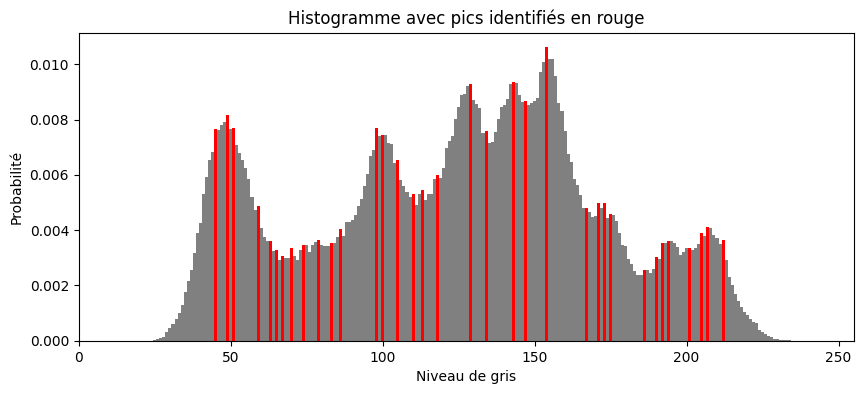

In [7]:
plt.figure(figsize=(10, 4))
plt.bar(range(256), h, width=1, color='gray')

# Ajouter une barre rouge pour chaque pic
for x, y in peaks:
    plt.bar(x, y, width=1, color='red')

plt.xlim(xmin=0, xmax=255)
plt.title("Histogramme avec pics identifiés en rouge")
plt.xlabel("Niveau de gris")
plt.ylabel("Probabilité")
plt.show()

> Trouver les pics les plus significatifs : Les points dans $P_0$ forment une nouvelle courbe. L'opération de l'étape précédente est répétée sur cet ensemble. Nous obtenons donc:
> $$P_1 = \{ (p_i, h(p_i)) / h(p_i) > h(p_{i-1}) \text{ et } h(p_i) > h(p_{i+1}),\; p_i \in P_0 \}$$

Il faut donc réutiliser la fonction __compute_peaks__ sur son propre résultat pour diminuer le nombre de pics et ainsi obtenir des pics plus significatifs :

Nombre de pics significatifs (P_1): 9


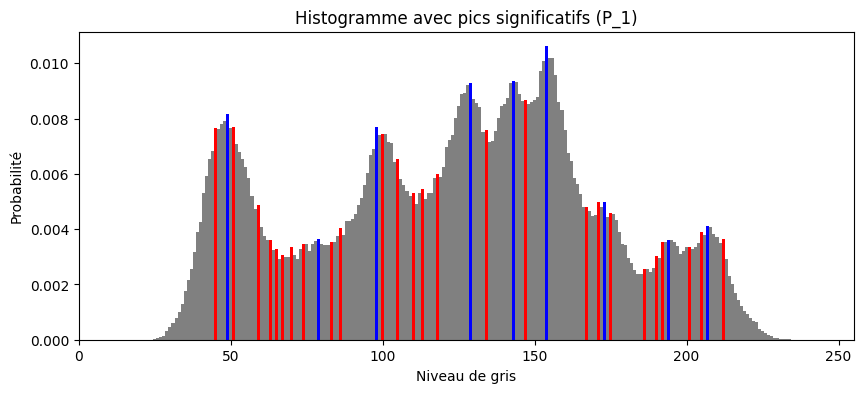

In [8]:
# Calcul de P_1 (pics significatifs) en utilisant compute_peaks avec iterations=2
peaks1 = compute_local_peaks(h, iterations=2)

print(f"Nombre de pics significatifs (P_1): {len(peaks1)}")

# On redessine l'histogramme avec P_1
plt.figure(figsize=(10, 4))
plt.bar(range(256), h, width=1, color='gray')

# On remet les barres rouges sur les pics précédents (P_0)
for x, y in peaks:
    plt.bar(x, y, width=1, color='red')

# On superpose des barres bleues pour les pics significatifs (P_1) pour visualiser l'évolution
for x, y in peaks1:
    plt.bar(x, y, width=1, color='blue')

plt.xlim(xmin=0, xmax=255)
plt.title("Histogramme avec pics significatifs (P_1)")
plt.xlabel("Niveau de gris")
plt.ylabel("Probabilité")
plt.show()

> Seuillage : Cette étape se décompose en trois phases :
>   - La première consiste à enlever les petits pics. Plus précisément, tous les pics dont la hauteur est inférieure à 5% de la hauteur du plus grand sont enlevés.
>   - Ensuite, si deux pics sont trop près l'un de l'autre, on ne retient que le plus grand. On considère que deux pics sont proches quand leur distance ($i_2-i_1$) est inférieure à 15 pixels.
>   - Si une vallée entre deux pics n'est pas assez prononcée, alors le pic le moins haut est éliminé. Plus précisément, si $p_1$ et $p_2$ sont les deux pics considérés alors la valeur moyenne $h_{avg}$ entre ces deux points est :
>     $$h_{avg} = \frac{\sum_{p_i=p_1}^{p_i=p_2} h(p_i)}{p_2 - p_1 + 1}$$
>
> En introduisant la valeur $h_{mean} = \frac{h(p_2) + h(p_1)}{2}$ qui représente la "mi-hauteur" des deux pics, on décide que la vallée n'est pas assez profonde lorsque $\frac{h_{avg}}{h_{mean}} > 0.75$; le pic le moins haut est alors retiré.

Nous allons définir la fonction suivante :
- __compute_seuillage__ : retourne l'ensemble réduit des pics après les trois phases de seuillage.

Nombre de pics restants après seuillage : 3


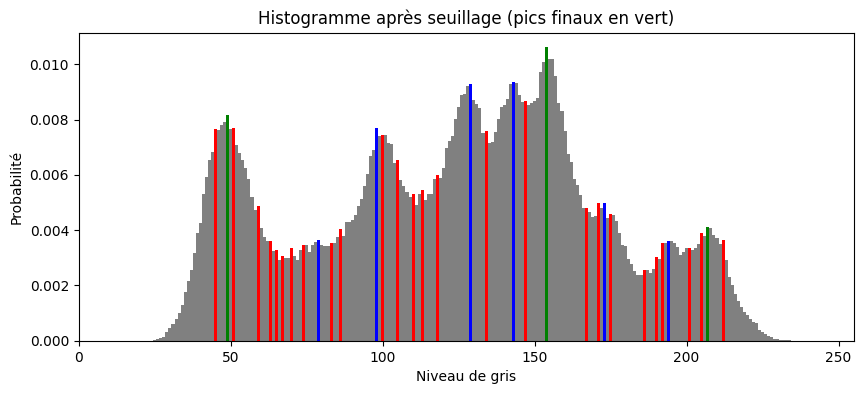

In [9]:
def compute_seuillage(h: np.ndarray, peaks: list[tuple[int, float]]) -> list[tuple[int, float]]:
    """
    Applique les trois phases de seuillage sur une liste de pics pour trouver l'ensemble réduit.
    """
    if not peaks:
        return []
        
    # Phase 1 : Enlever les petits pics (hauteur < 5% du plus grand pic)
    max_height = max(p[1] for p in peaks)
    result_peaks = [p for p in peaks if p[1] >= 0.05 * max_height]

    # Phase 2 : Enlever les pics trop proches (distance < 15)
    i = 0
    while i < len(result_peaks) - 1:
        if result_peaks[i+1][0] - result_peaks[i][0] < 15:
            # On ne garde que le plus grand des deux
            if result_peaks[i][1] > result_peaks[i+1][1]:
                result_peaks.pop(i+1)
            else:
                result_peaks.pop(i)
        else:
            i += 1

    # Phase 3 : Vérifier la profondeur de la vallée
    i = 0
    while i < len(result_peaks) - 1:
        p1, h1 = result_peaks[i]
        p2, h2 = result_peaks[i+1]
        
        # Calcul de la moyenne de l'histogramme entre p1 et p2 (inclus)
        havg = sum(h[p1:p2+1]) / (p2 - p1 + 1)
        
        # Calcul de la "mi-hauteur"
        hmean = (h1 + h2) / 2.0
        
        # Si la vallée n'est pas assez profonde, on enlève le plus petit pic
        if (havg / hmean) > 0.75:
            if h1 > h2:
                result_peaks.pop(i+1)
            else:
                result_peaks.pop(i)
        else:
            i += 1
            
    return result_peaks

peaks2 = compute_seuillage(h, peaks1)
print(f"Nombre de pics restants après seuillage : {len(peaks2)}")

# On redessine l'histogramme avec les pics restants après seuillage
plt.figure(figsize=(10, 4))
plt.bar(range(256), h, width=1, color='gray')

# (Facultatif) On peut remettre les anciens pics pour comparer
for x, y in peaks:
    plt.bar(x, y, width=1, color='red')
for x, y in peaks1:
    plt.bar(x, y, width=1, color='blue')

# On superpose des barres vertes pour les pics finaux (après seuillage)
for x, y in peaks2:
    plt.bar(x, y, width=1, color='green')

plt.xlim(xmin=0, xmax=255)
plt.title("Histogramme après seuillage (pics finaux en vert)")
plt.xlabel("Niveau de gris")
plt.ylabel("Probabilité")
plt.show()

> - une fonction qui a pour argument une image à niveaux de gris et en sortie un vecteur contenant les seuils détectés.

Nous allons définir la fonction suivante :
- __detect_vallees_compute_seuils__ : retourne un vecteur contenant les seuils détectés suivant la méthode de seuillage par détection des vallées

In [10]:
def detect_vallees_compute_seuils(matrix: np.ndarray) -> list[int]:
    """
    Détecte les seuils d'une image selon la méthode de détection des vallées.
    
    Args:
        matrix: L'image en niveaux de gris (np.ndarray).
        
    Returns:
        Une liste de niveaux de gris représentant les seuils (vallées entre les pics finaux).
    """
    # 1. Calcul de l'histogramme normalisé
    h = compute_histogram(matrix, normalized=True)
    
    # 2. Détection des pics avec 2 itérations (comme fait précédemment)
    peaks1 = compute_local_peaks(h, iterations=2)
    
    # 3. Filtrage avec notre fonction de seuillage
    final_peaks = compute_seuillage(h, peaks1)
    
    # 4. Déterminer les vallées = seuils entre les pics finaux
    seuils = []
    for i in range(len(final_peaks) - 1):
        p1 = final_peaks[i][0]
        p2 = final_peaks[i+1][0]
        
        # Trouver l'indice (niveau de gris) minimum de l'histogramme entre p1 et p2
        # np.argmin renvoie l'index relatif au sous-tableau `h[p1:p2+1]`, donc on ajoute p1
        valley_idx = p1 + np.argmin(h[p1:p2+1])
        seuils.append(int(valley_idx))
        
    return seuils

# Testons la fonction sur notre image m
seuils_test = detect_vallees_compute_seuils(m)
print(f"Seuils détectés : {seuils_test}")

Seuils détectés : [66, 184]


> - Une fonction qui a pour entrée en argument une image I à niveaux de gris et un vecteur de seuils et en sortie une image segmentée où chaque région a une étiquette différente.

En utilisant la fonction __detect_vallees_compute_seuils__ définie ci-dessus, nous allons ségmenter une image en conservant qu'un unique canal de couleur mais suivant le standard viridis pour différencier les régions.

Ainsi, nous allons définir la fonction suivante :
- __detect_vallees_compute_image__ : retourne une image segmentée selon les seuils détectés suivant la méthode de seuillage par détection des vallées

Aperçu de la matrice segmentée m_segmented :
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]]
shape=(512, 512), dtype=int64, valeurs uniques (étiquettes)=[0 1 2]


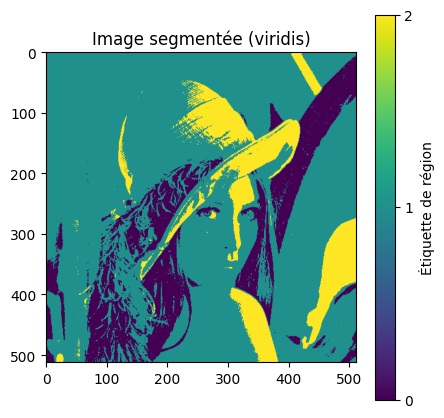

In [11]:
def detect_vallees_compute_image(matrix: np.ndarray, seuils: list[int]) -> np.ndarray:
    """
    Segmente une image en niveaux de gris à l'aide d'un vecteur de seuils.
    
    Args:
        matrix: Matrice de l'image (np.ndarray).
        seuils: Liste ordonnée des seuils détectés.
        
    Returns:
        np.ndarray: Une matrice de la même taille où chaque pixel possède son étiquette de région (0, 1, 2...).
    """
    # np.digitize affecte chaque valeur de la matrice à un intervalle défini par "seuils".
    # Les pixels ayant une valeur < seuils[0] auront l'étiquette 0,
    # les pixels entre seuils[0] et seuils[1] auront l'étiquette 1, etc.
    segmented = np.digitize(matrix, bins=seuils)
    
    return segmented

# Testons la segmentation sur la matrice 'm' avec les seuils 'seuils_test' générés précédemment
m_segmented = detect_vallees_compute_image(m, seuils_test)

# Affichage textuel pour apprécier sa composition matricielle
print("Aperçu de la matrice segmentée m_segmented :")
print(m_segmented)
print(f"shape={m_segmented.shape}, dtype={m_segmented.dtype}, valeurs uniques (étiquettes)={np.unique(m_segmented)}")

# Affichage avec colormap viridis comme demandé
plt.figure(figsize=(5, 5))
# viridis est la cmap par défaut, c'est comme cela que nous l'avons découverte
# donc le paramètre cmap='viridis' est optionnel
plt.imshow(m_segmented)
plt.title("Image segmentée (viridis)")
plt.colorbar(ticks=range(len(seuils_test) + 1), label="Étiquette de région")
plt.show()

> - Un script, qui lit une image en vous proposant d'aller la chercher dans un répertoire (utiliser la fonction *uigetfile*), si l'image est en couleur alors la transformer en image à niveaux de gris. Vous appelez les fonctions nécessaires pour segmenter l'image et les visualiser côte à côte sur un seul graphique (utiliser *subplot*).

Nous n'avons pas utiliser scilab mais python, ainsi nous allons utiliser ajouter une liste déroulante pour que l'utilisateur puisse choisir une des images présentes dans le dossier `img`.  
*Nous ne pouvons pas laisser l'utilisateur choisir au début du notebook car l'entrée interactive (le chemin de l'image) ne doit être utilisée que dans cette même cellule sinon il serait nécessaire de réexécuter l'ensemble des cellules suivantes.*


In [12]:
import os
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

# On liste les fichiers images présents dans le dossier 'img'
if os.path.exists("img"):
    image_files = [f for f in os.listdir("img") if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
else:
    image_files = []

dropdown_script = widgets.Dropdown(
    options=image_files,
    description='Image:',
    disabled=False,
)

def process_and_display(image_filename):
    if not image_filename:
        print("Aucune image sélectionnée.")
        return
        
    path = os.path.join("img", image_filename)
    
    # 1. Lier et transformer en image en niveaux de gris
    # (la fonction load_image_matrix gère la conversion)
    matrix = load_image_matrix(path)
    
    # 2. Appeler les fonctions nécessaires pour segmenter l'image
    seuils = detect_vallees_compute_seuils(matrix)
    print(f"Seuils détectés pour {image_filename} : {seuils}")
    segmented = detect_vallees_compute_image(matrix, seuils)
    
    # 3. Visualiser côte à côte sur un seul graphique (subplot)
    # Une colonne dédiée à la colorbar évite de rétrécir l'image segmentée.
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12, 6),
        gridspec_kw={"width_ratios": [1, 1, 0.05]},
    )
    
    # Image originale en niveaux de gris
    # vmin=0, vmax=255 est important sinon matplotlib extrapole les niveaux de gris pour toutes les images qui n'ont pas de blanc pur (255) ou de noir pur (0)
    # Exemple mon degrade-25x25.png n'est que de niveau 58 à 74 mais est affiché de 0 à 255 sans vmin/vmax
    axes[0].imshow(matrix, cmap='gray', vmin=0, vmax=255, aspect='equal')
    axes[0].set_title(f"Image originale : {image_filename}")
    axes[0].axis('off')
    
    # Image segmentée avec les couleurs viridis
    im_seg = axes[1].imshow(segmented, aspect='equal')
    axes[1].set_title("Image segmentée (Vallées)")
    axes[1].axis('off')
    
    # Barre de couleur référençant les classes de segmentation
    fig.colorbar(im_seg, cax=axes[2], ticks=range(len(seuils) + 1), label="Étiquette de région")
    axes[2].set_ylabel("Étiquette de région")
    
    plt.tight_layout()
    plt.show()

# Lier le widget de sélection à notre fonction d'affichage
out_script = widgets.interactive_output(process_and_display, {'image_filename': dropdown_script})

display(dropdown_script, out_script)

Dropdown(description='Image:', options=('chromosome.bmp', 'degrade-25x25.png', 'image2.png', 'image3.png', 'Im…

Output()

> - Me rendre plusieurs exemples d'images segmentées.

In [13]:
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

def export_segmented_image(image_filename):
    if not image_filename:
        return

    path = os.path.join("img", image_filename)
    matrix = load_image_matrix(path)
    seuils = detect_vallees_compute_seuils(matrix)
    segmented = detect_vallees_compute_image(matrix, seuils)

    output_path = os.path.join(
        output_dir, f"{os.path.splitext(image_filename)[0]}_segmentée.png"
    )

    plt.imsave(output_path, segmented, cmap="viridis")
    print(f"Image segmentée exportée : {output_path}")
    
for image_filename in image_files:
    export_segmented_image(image_filename)


Image segmentée exportée : output\chromosome_segmentée.png
Image segmentée exportée : output\degrade-25x25_segmentée.png
Image segmentée exportée : output\image2_segmentée.png
Image segmentée exportée : output\image3_segmentée.png


Image segmentée exportée : output\ImageTest avec arrière-plan supprimé_segmentée.png
Image segmentée exportée : output\ImageTest_segmentée.png
Image segmentée exportée : output\lena_segmentée.png
Image segmentée exportée : output\scene_segmentée.png
Image segmentée exportée : output\suzan_segmentée.png


## Script sur une autre image

Si vous souhaitez tester le code du notebook sur une autre image, ajoutez votre image dans le dossier `img` et lancer main.py sans paramètre, vous trouverez votre image segmentée dans le dossier `output`.

L'intégralité du contenu de `main.py` est exactement le code du notebook avec uniquement les _plt.show()_ qui sont commentés pour que le script ne soit pas interactif.